# Exercise 01: RL Fundamentals and MDPs
## AIAT 123 - Reinforcement Learning

---

## Learning Objectives

In this exercise, you will:
- Define Markov Decision Processes (MDPs)
- Implement value iteration algorithm
- Evaluate and compare policies
- Solve simple RL problems

---

## Real-World Context

You are solving a grid world navigation problem where an agent must find the optimal path to a goal while avoiding obstacles.

---


## Exercise Brief

This exercise checks whether students can do the core Unit 1 work on their own.

They must define an MDP clearly, run value iteration, and compare policies with short explanations.

Why this matters: Unit 1 is the conceptual base of the whole course, so students should not leave it with passive understanding only.

This exercise is designed to verify that the ideas from the lesson notebooks are now usable.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- State: where the agent is.
- Action: what the agent can do.
- Reward: immediate feedback.
- Policy: the action rule.

### Quick Check
- Can you separate environment pieces from agent pieces?
- Why do we define states and actions before solving?
- What part of the notebook tells you what success means?

### Common Mistakes
- Mixing state with reward.
- Thinking the policy creates the reward.
- Reading one transition as the whole problem.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install numpy -q

# Import names from a package/module into the notebook kernel namespace.
import numpy as np

# Call a NumPy helper (array creation, options, or array conversion).
np.set_printoptions(precision=2, suppress=True)

# Print text to the notebook cell output (console).
print("✅ Setup complete!")
# Print text to the notebook cell output (console).
print("This exercise uses a small 3x3 grid-world MDP.")


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.
✅ Setup complete!
This exercise uses a small 3x3 grid-world MDP.


## Task 1: MDP Definition (25 points)

Define the MDP for a simple problem (grid world, maze, or similar).

**Requirements:**
- Define states
- Define actions
- Define transition probabilities
- Define reward function

Teaching note: if your environment is deterministic, you can still describe transition probabilities. They are just concentrated on one outcome, so the chosen transition has probability `1.0`.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Starter environment for Task 1
# Set grid height and width in cells (3x3 in this toy MDP).
N_ROWS, N_COLS = 3, 3
# Total number of states = rows * columns (flattened indices 0..N-1).
N_STATES = N_ROWS * N_COLS
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = ["up", "right", "down", "left"]
# Assign/update a variable used later in this cell or in other cells.
ACTION_TO_DELTA = {
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    0: (-1, 0),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    1: (0, 1),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    2: (1, 0),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    3: (0, -1),
# Part of a dict/set literal layout (syntax grouping).
}
# Pick which flat state ids are special terminals for rewards in transition().
GOAL_STATE = 8
# Pick which flat state ids are special terminals for rewards in transition().
PIT_STATE = 6
# Build the set of terminal state ids (used to skip Bellman backups).
TERMINAL_STATES = {GOAL_STATE, PIT_STATE}
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA = 0.90


# Function `to_pos` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state.
def to_pos(state):
    # Return a value from this function to its caller.
    return divmod(state, N_COLS)


# Function `to_state` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: row, col.
def to_state(row, col):
    # Return a value from this function to its caller.
    return row * N_COLS + col


# Task 1a: complete the transition function.
# Function `transition` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def transition(state, action):
    # Branch: only run the next indented lines when this condition is true.
    if state in TERMINAL_STATES:
        # Return a value from this function to its caller.
        return state, 0.0

    # Assign/update a variable used later in this cell or in other cells.
    row, col = to_pos(state)
    # Assign/update a variable used later in this cell or in other cells.
    d_row, d_col = ACTION_TO_DELTA[action]
    # Assign/update a variable used later in this cell or in other cells.
    next_row = min(max(row + d_row, 0), N_ROWS - 1)
    # Assign/update a variable used later in this cell or in other cells.
    next_col = min(max(col + d_col, 0), N_COLS - 1)
    # Unpack the one-step model output from transition(state, action).
    next_state = to_state(next_row, next_col)

    # Branch: only run the next indented lines when this condition is true.
    if next_state == GOAL_STATE:
        # Return a value from this function to its caller.
        return next_state, 10.0
    # Branch: only run the next indented lines when this condition is true.
    if next_state == PIT_STATE:
        # Return a value from this function to its caller.
        return next_state, -10.0
    # Return a value from this function to its caller.
    return next_state, -1.0


# Task 1b: print example transitions to confirm your MDP definition.
# Loop header: repeat the indented block for each item in the iterable.
for action in range(4):
    # Print text to the notebook cell output (console).
    print(f"state 4 + action {ACTIONS[action]} ->", transition(4, action))


state 4 + action up -> (1, -1.0)
state 4 + action right -> (5, -1.0)
state 4 + action down -> (7, -1.0)
state 4 + action left -> (3, -1.0)


## Task 2: Value Iteration (40 points)

Implement the value iteration algorithm to find optimal value function.

**Requirements:**
- Implement value iteration
- Handle convergence
- Visualize value function
- Extract optimal policy


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Task 2: value iteration

# Function `value_iteration` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: gamma, theta.
def value_iteration(gamma=GAMMA, theta=1e-6):
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(N_STATES)
    # Loop header: repeat while the condition stays true.
    while True:
        # Track how much the value table moved during the current sweep (or max change).
        delta = 0.0
        # Hold the updated V table for this sweep before swapping it into values.
        new_values = values.copy()
        # Loop header: repeat the indented block for each item in the iterable.
        for state in range(N_STATES):
            # Branch: only run the next indented lines when this condition is true.
            if state in TERMINAL_STATES:
                # Skip the rest of this loop body and jump to the next iteration.
                continue
            # Create a Python list that will store one scalar target per action.
            action_returns = []
            # Loop header: repeat the indented block for each item in the iterable.
            for action in range(len(ACTIONS)):
                # Unpack the one-step model output from transition(state, action).
                next_state, reward = transition(state, action)
                # Append one value to a list (mutates the list in place).
                action_returns.append(reward + gamma * values[next_state])
            # Take the Bellman optimality max over the per-action backup list.
            best_value = max(action_returns)
            # Track how much the value table moved during the current sweep (or max change).
            delta = max(delta, abs(best_value - values[state]))
            # Hold the updated V table for this sweep before swapping it into values.
            new_values[state] = best_value
        # Create or choose a variable used in the Bellman warm-up demo.
        values = new_values
        # Branch: only run the next indented lines when this condition is true.
        if delta < theta:
            # Exit the nearest enclosing loop immediately.
            break
    # Return a value from this function to its caller.
    return values


# Task 2a: run value iteration.
# Create or choose a variable used in the Bellman warm-up demo.
values = value_iteration()
# Print text to the notebook cell output (console).
print("Optimal values:", values)

# Task 2b: write a short explanation in markdown below:
# Why are states close to the goal higher-value than states near the pit?


Optimal values: [ 4.58  6.2   8.    6.2   8.   10.    0.   10.    0.  ]


## Task 3: Policy Evaluation (35 points)

Evaluate different policies and compare their performance.

**Requirements:**
- Implement policy evaluation
- Compare multiple policies
- Visualize policy performance
- Analyze results


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [4]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Task 3: policy evaluation and comparison

# Function `evaluate_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy, gamma, theta.
def evaluate_policy(policy, gamma=GAMMA, theta=1e-6):
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(N_STATES)
    # Loop header: repeat while the condition stays true.
    while True:
        # Track how much the value table moved during the current sweep (or max change).
        delta = 0.0
        # Loop header: repeat the indented block for each item in the iterable.
        for state in range(N_STATES):
            # Branch: only run the next indented lines when this condition is true.
            if state in TERMINAL_STATES:
                # Skip the rest of this loop body and jump to the next iteration.
                continue
            # Assign/update a variable used later in this cell or in other cells.
            action = policy[state]
            # Unpack the one-step model output from transition(state, action).
            next_state, reward = transition(state, action)
            # Assign/update a variable used later in this cell or in other cells.
            new_value = reward + gamma * values[next_state]
            # Track how much the value table moved during the current sweep (or max change).
            delta = max(delta, abs(new_value - values[state]))
            # Create or choose a variable used in the Bellman warm-up demo.
            values[state] = new_value
        # Branch: only run the next indented lines when this condition is true.
        if delta < theta:
            # Exit the nearest enclosing loop immediately.
            break
    # Return a value from this function to its caller.
    return values


# Create or update the greedy policy array (one int action id per state).
policy_a = np.array([1, 1, 2, 1, 1, 2, 0, 1, 0])
# Create or update the greedy policy array (one int action id per state).
policy_b = np.array([1, 1, 2, 0, 0, 2, 0, 1, 0])

# Create or choose a variable used in the Bellman warm-up demo.
values_a = evaluate_policy(policy_a)
# Create or choose a variable used in the Bellman warm-up demo.
values_b = evaluate_policy(policy_b)

# Print text to the notebook cell output (console).
print("Policy A values:", values_a)
# Print text to the notebook cell output (console).
print("Policy B values:", values_b)

# Task 3a: compare the two policies.
# Task 3b: explain which policy is safer and why.
# Task 3c: identify one state where the policy choice matters most.


Policy A values: [ 4.58  6.2   8.    6.2   8.   10.    0.   10.    0.  ]
Policy B values: [ 4.58  6.2   8.    3.12  4.58 10.    0.   10.    0.  ]



---

## Submission

**Submission**: Complete notebook with all tasks implemented

**Grading**: 100 points total


## Reflection

Before submitting, make sure you can explain:

- how you defined the MDP
- how value iteration used the Bellman update
- why one policy performed better than another
- what the reward function encouraged in this environment

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [5]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Submission checklist moved to the markdown cell below.

## Submission Checklist

Use this checklist before you submit:

- [ ] I defined the states, actions, terminal states, and rewards clearly.
- [ ] I ran value iteration successfully.
- [ ] I compared at least two policies.
- [ ] I wrote short explanations, not just code output.
- [ ] I checked my reasoning against the Unit 1 notes before submitting.

## 📝 Summary

In this notebook, you practiced:
- Formalizing a problem as a **Markov Decision Process** (states, actions, transition function, rewards, discount factor γ)
- Implementing **value iteration** to compute the optimal value function V*(s)
- Extracting an **optimal policy** from the value function using greedy action selection
- Solving a grid-world navigation task and evaluating different policies

**Next steps:** Move to Q-learning and Deep Q-Networks (Unit 3) to tackle environments where the state space is too large for tabular methods.

## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


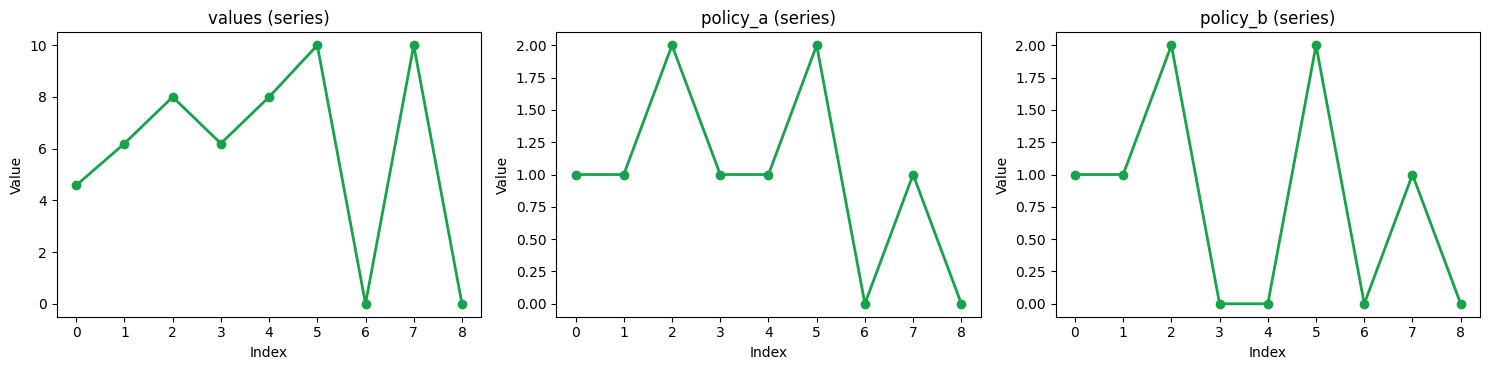

In [6]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # More on the same axes object (limits, ticks, labels, artists).
    ax.set_title("Notebook artifact summary")
    # More on the same axes object (limits, ticks, labels, artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # More on the same axes object (limits, ticks, labels, artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xticks(range(len(values)))
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (dict)")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # More on the same axes object (limits, ticks, labels, artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (series)")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xlabel("Index")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise confirms that students can define and solve a small RL problem without relying on guided explanation.

**If students remember one idea:** If a student can clearly define the MDP and justify the policy behavior, then Unit 1 concepts are becoming usable knowledge.

**Quick check before moving on:**
- Can you justify each part of your MDP design rather than only writing it down?
- Can you explain what your policy or values mean in plain language?

**Bridge to the next step:** After this exercise, students are ready to learn how value functions and policies are learned from experience in Unit 2.
